# TreeViz Python Notebook

This notebook builds a TreeViz-native `.treeviz.json` session from a self-contained phylogenetic tree and metadata table, displays the interactive TreeViz view inline, and renders static PNG/SVG exports for reports. The example uses synthetic coronavirus-style surveillance labels so it can run without external data files.

## Setup

Use the Pixi Python environment for interactive runs. On `nb.newlineages.com`, select `Python (Pixi)`; that kernel finds the parent `pixi.toml` for this checkout. From a local shell, you can also launch Jupyter with `pixi run -e py jupyter lab docs/examples/python-notebook.ipynb` and select `Python 3` from that Pixi-launched server.

This cell locates the repository, verifies the active kernel, imports the local wrapper, and records the active Python and Bun paths used later for static export. If the notebook is opened under a system Python kernel, it attempts to install the repo-local Pixi kernel and stops so you can switch kernels before continuing.


In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import sys
import html

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "packages/python/src/treeviz").exists()
)
expected_envs = [
    repo_root / ".pixi" / "envs" / "py",
    repo_root / ".pixi" / "envs" / "default",
]
active_python = Path(sys.executable).resolve()

if not any(active_python.is_relative_to(env) for env in expected_envs):
    pixi = shutil.which("pixi")
    install_note = ""
    if pixi is not None:
        completed = subprocess.run(
            [pixi, "run", "-e", "py", "py-kernel-local"],
            cwd=repo_root,
            capture_output=True,
            text=True,
        )
        install_note = (completed.stdout + completed.stderr).strip()
    raise RuntimeError(
        "This notebook is running under the wrong Python kernel:\n"
        f"  {active_python}\n"
        "On nb.newlineages.com, select the Jupyter kernel named 'Python (Pixi)'. "
        "For local Jupyter servers, select 'TreeViz (pixi py)' after the Pixi kernel install. "
        "Then restart/run all cells.\n"
        f"Pixi kernel install output:\n{install_note or 'pixi was not found on PATH'}"
    )

from IPython.display import HTML, Image, display
import pandas as pd

sys.path.insert(0, str(repo_root / "packages/python/src"))

from treeviz import build_session, save_session, validate_session, view_tree


def find_bun():
    candidates = []
    discovered = shutil.which("bun")
    if discovered:
        candidates.append(Path(discovered))
    candidates.extend([
        Path.home() / ".bun" / "bin" / "bun",
        repo_root / ".bun" / "bin" / "bun",
    ])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


bun_path = find_bun()
{
    "repo_root": str(repo_root),
    "python": str(active_python),
    "bun": str(bun_path) if bun_path else "not found",
}


{'repo_root': '/workspace/dev/treeviz',
 'python': '/workspace/dev/treeviz/.pixi/envs/default/bin/python3.12',
 'bun': '/workspace/home/.bun/bin/bun'}

## Demo Data

Define one Newick tree, one metadata row per leaf, and the track configuration that will be shared by the saved session and inline view. The metadata key column is `id`, matching the leaf labels exactly.

In [2]:
newick = """
(((HCoV_HKU1_USA_2024:0.045,HCoV_HKU1_Germany_2023:0.050)92:0.030,
  (HCoV_OC43_Brazil_2024:0.060,HCoV_OC43_Japan_2022:0.055)88:0.035)95:0.070,
 ((Bat_CoV_RsYN04_China_2021:0.075,Bat_CoV_RmYN02_China_2019:0.080)91:0.055,
  ((Pangolin_CoV_GD_2019:0.070,Pangolin_CoV_GX_2020:0.072)86:0.045,
   (SARS2_BA2_USA_2022:0.040,SARS2_XBB_India_2023:0.042,SARS2_JN1_France_2024:0.044)97:0.050)93:0.060)96:0.080,
 ((MERS_CoV_Saudi_2019:0.090,MERS_CoV_Qatar_2020:0.085)89:0.060,
  (Camel_CoV_Kenya_2021:0.095,Camel_CoV_UAE_2022:0.088)84:0.055)90:0.085);
""".strip()

metadata = pd.DataFrame(
    [
        {"id": "HCoV_HKU1_USA_2024", "host": "human", "region": "North America", "lineage": "HKU1", "genome_kb": 29.7, "gc_pct": 32.1, "read_depth": 520, "surveillance": "clinical", "risk_score": 0.42},
        {"id": "HCoV_HKU1_Germany_2023", "host": "human", "region": "Europe", "lineage": "HKU1", "genome_kb": 29.8, "gc_pct": 32.0, "read_depth": 480, "surveillance": "clinical", "risk_score": 0.39},
        {"id": "HCoV_OC43_Brazil_2024", "host": "human", "region": "South America", "lineage": "OC43", "genome_kb": 30.5, "gc_pct": 36.7, "read_depth": 610, "surveillance": "clinical", "risk_score": 0.48},
        {"id": "HCoV_OC43_Japan_2022", "host": "human", "region": "Asia", "lineage": "OC43", "genome_kb": 30.6, "gc_pct": 36.5, "read_depth": 390, "surveillance": "clinical", "risk_score": 0.44},
        {"id": "Bat_CoV_RsYN04_China_2021", "host": "bat", "region": "Asia", "lineage": "sarbecovirus", "genome_kb": 29.9, "gc_pct": 38.0, "read_depth": 210, "surveillance": "wildlife", "risk_score": 0.71},
        {"id": "Bat_CoV_RmYN02_China_2019", "host": "bat", "region": "Asia", "lineage": "sarbecovirus", "genome_kb": 29.7, "gc_pct": 37.9, "read_depth": 180, "surveillance": "wildlife", "risk_score": 0.68},
        {"id": "Pangolin_CoV_GD_2019", "host": "pangolin", "region": "Asia", "lineage": "sarbecovirus", "genome_kb": 29.8, "gc_pct": 38.2, "read_depth": 155, "surveillance": "wildlife", "risk_score": 0.64},
        {"id": "Pangolin_CoV_GX_2020", "host": "pangolin", "region": "Asia", "lineage": "sarbecovirus", "genome_kb": 29.6, "gc_pct": 38.1, "read_depth": 170, "surveillance": "wildlife", "risk_score": 0.62},
        {"id": "SARS2_BA2_USA_2022", "host": "human", "region": "North America", "lineage": "SARS-CoV-2", "genome_kb": 29.9, "gc_pct": 37.9, "read_depth": 960, "surveillance": "clinical", "risk_score": 0.77},
        {"id": "SARS2_XBB_India_2023", "host": "human", "region": "Asia", "lineage": "SARS-CoV-2", "genome_kb": 29.9, "gc_pct": 37.8, "read_depth": 1040, "surveillance": "clinical", "risk_score": 0.81},
        {"id": "SARS2_JN1_France_2024", "host": "human", "region": "Europe", "lineage": "SARS-CoV-2", "genome_kb": 29.9, "gc_pct": 37.8, "read_depth": 1120, "surveillance": "clinical", "risk_score": 0.84},
        {"id": "MERS_CoV_Saudi_2019", "host": "human", "region": "Middle East", "lineage": "MERS", "genome_kb": 30.1, "gc_pct": 41.2, "read_depth": 430, "surveillance": "clinical", "risk_score": 0.73},
        {"id": "MERS_CoV_Qatar_2020", "host": "human", "region": "Middle East", "lineage": "MERS", "genome_kb": 30.1, "gc_pct": 41.1, "read_depth": 365, "surveillance": "clinical", "risk_score": 0.69},
        {"id": "Camel_CoV_Kenya_2021", "host": "camel", "region": "Africa", "lineage": "MERS-related", "genome_kb": 30.2, "gc_pct": 41.4, "read_depth": 245, "surveillance": "livestock", "risk_score": 0.58},
        {"id": "Camel_CoV_UAE_2022", "host": "camel", "region": "Middle East", "lineage": "MERS-related", "genome_kb": 30.2, "gc_pct": 41.5, "read_depth": 275, "surveillance": "livestock", "risk_score": 0.60},
    ]
)

tracks = [
    {"id": "host", "kind": "color_strip", "column_key": "host", "title": "Host", "width": 18, "palette": "tableau10"},
    {"id": "region", "kind": "color_strip", "column_key": "region", "title": "Region", "width": 18, "palette": "set2"},
    {"id": "genome-qc", "kind": "heatmap", "column_keys": ["genome_kb", "gc_pct"], "title": "Genome QC", "cell_width": 18, "palette": "magma"},
    {"id": "read-depth", "kind": "bar", "column_key": "read_depth", "title": "Read depth", "width": 84, "color": "#2563eb", "show_axis": True, "axis_position": "top", "show_helper_lines": True},
    {"id": "risk-score", "kind": "gradient", "column_key": "risk_score", "title": "Risk score", "width": 48, "palette": "viridis"},
]

view_settings = {
    "layout": "rectangular",
    "branchScale": 1,
    "leafSpacing": 0.95,
    "metadataScale": 1,
    "metadataGap": 1,
    "labelFontSize": 11,
    "allowLabelOverlap": False,
    "tipAlignment": "label",
    "figureLegendVisible": False,
    "figureLegendSections": {
        "host": {"visible": True, "position": {"x": 20, "y": 20}},
        "region": {"visible": True, "position": {"x": 170, "y": 20}},
    },
    "figureLegendTextOverrides": {
        "host": {"title": "Host"},
        "region": {"title": "Sampling region"},
        "genome-qc": {"title": "Genome quality metrics"},
        "read-depth": {"title": "Read depth"},
        "risk-score": {"title": "Risk score"},
    },
}


## Track Context

Show the visual encoding plan before rendering. This makes the notebook self-explanatory even when the interactive iframe is viewed separately from the surrounding prose.

In [3]:
track_legend = pd.DataFrame(
    [
        {"track": "Host", "encoding": "categorical color strip", "metadata": "host"},
        {"track": "Region", "encoding": "categorical color strip", "metadata": "region"},
        {"track": "Genome QC", "encoding": "two-column heatmap", "metadata": "genome_kb, gc_pct"},
        {"track": "Read depth", "encoding": "bar track with helper lines", "metadata": "read_depth"},
        {"track": "Risk score", "encoding": "continuous gradient", "metadata": "risk_score"},
    ]
)

display(track_legend)
metadata.groupby(["host", "surveillance"]).size().rename("tips").reset_index()


,track,encoding,metadata
0,Host,categorical color strip,host
1,Region,categorical color strip,region
2,Genome QC,two-column heatmap,"genome_kb, gc_pct"
3,Read depth,bar track with helper lines,read_depth
4,Risk score,continuous gradient,risk_score


,host,surveillance,tips
0,bat,wildlife,2
1,camel,livestock,2
2,human,clinical,9
3,pangolin,wildlife,2


## Interactive TreeViz View

Build, validate, and save the session, then display the same session inline with `view_tree`. The assertion checks that the iframe view and saved session use identical track configuration. If your notebook frontend shows a blank iframe, use the browser link below it or the static PNG in the next section.


In [4]:
session_name = "Coronavirus surveillance tree"
output_dir = Path("/tmp")
session_path = output_dir / "treeviz-notebook-coronavirus.treeviz.json"

session = build_session(
    newick,
    metadata=metadata,
    tracks=tracks,
    view=view_settings,
    name=session_name,
)
validate_session(session)
save_session(session, session_path)

view = view_tree(
    newick,
    metadata=metadata,
    tracks=tracks,
    view=view_settings,
    name=session_name,
    open_browser=False,
)
assert view.session["tracks"] == session["tracks"]
assert view.fragment is not None

view_url = view.url
display(view)
display(HTML(f'<p><a href="{html.escape(view_url)}" target="_blank" rel="noopener noreferrer">Open this TreeViz session in a browser</a></p>'))
{
    "session": str(session_path),
    "tips": len(session["binding"]["matches"]),
    "tracks": len(session["tracks"]),
    "iframe_fragment_chars": len(view.fragment),
}


{'session': '/tmp/treeviz-notebook-coronavirus.treeviz.json',
 'tips': 15,
 'tracks': 5,
 'iframe_fragment_chars': 3641}

## Static Export

Render the saved session through the TreeViz CLI at a tighter report-friendly viewport. The PNG is displayed in the notebook and the SVG remains available for vector workflows. This cell uses the Bun path found during setup, so it works even when the Jupyter kernel PATH does not include `bun`.


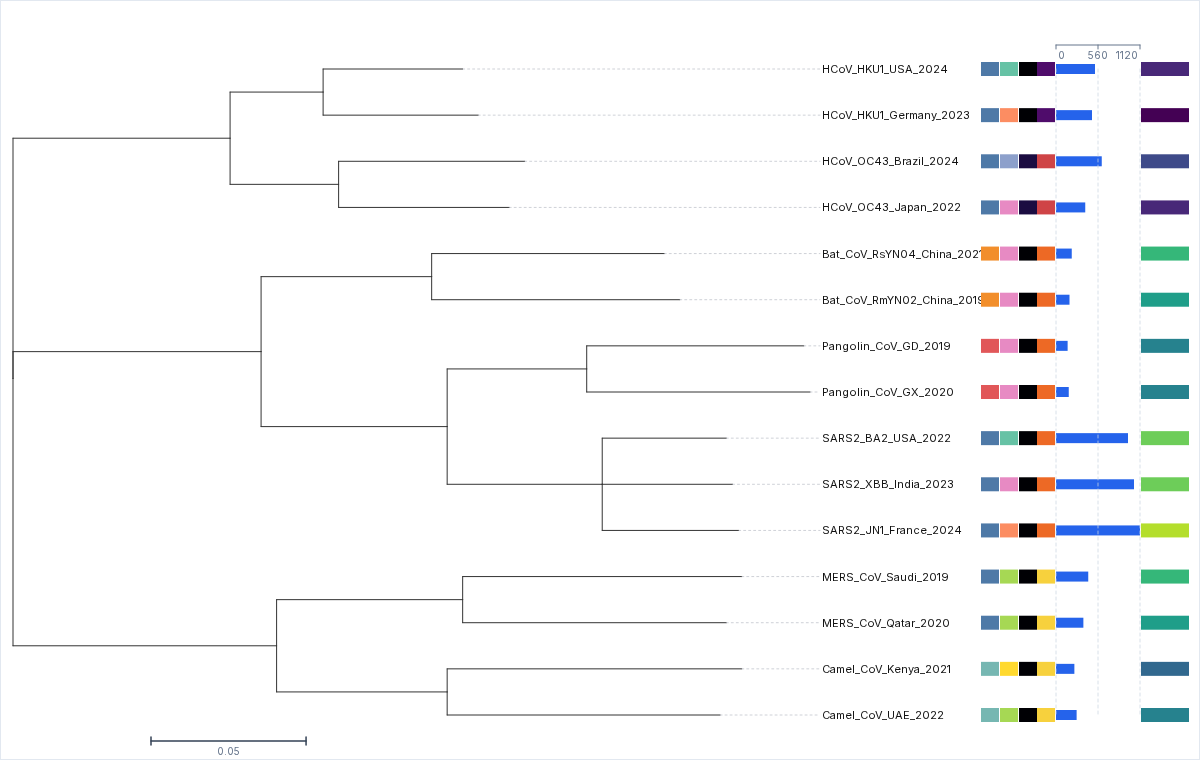

{'png': '/tmp/treeviz-notebook-coronavirus.png',
 'svg': '/tmp/treeviz-notebook-coronavirus.svg',
 'size': '1200x760'}

In [5]:
png_path = output_dir / "treeviz-notebook-coronavirus.png"
svg_path = output_dir / "treeviz-notebook-coronavirus.svg"
render_width = 1200
render_height = 760

if bun_path is None:
    raise FileNotFoundError(
        "TreeViz static export needs Bun. Launch Jupyter with "
        "'pixi run -e py jupyter lab docs/examples/python-notebook.ipynb', "
        "install the named kernel with 'pixi run -e py py-kernel', or install Bun from https://bun.sh."
    )

render_env = os.environ.copy()
render_env.pop("FORCE_COLOR", None)
render_env["NO_COLOR"] = "1"
render_env["PATH"] = f"{bun_path.parent}{os.pathsep}{render_env.get('PATH', '')}"

for output_format, output_path in [("png", png_path), ("svg", svg_path)]:
    subprocess.run(
        [
            str(bun_path),
            "src/cli/cli.ts",
            "render",
            str(session_path),
            "--format",
            output_format,
            "--width",
            str(render_width),
            "--height",
            str(render_height),
            "-o",
            str(output_path),
        ],
        cwd=repo_root,
        env=render_env,
        capture_output=True,
        check=True,
        text=True,
    )

assert png_path.exists()
assert svg_path.exists()
display(Image(filename=str(png_path)))
{"png": str(png_path), "svg": str(svg_path), "size": f"{render_width}x{render_height}"}
